# Análisis CLV completo — BG/NBD + Gamma-Gamma

Notebook principal del TFM. Integra los dos modelos del marco BTYD bayesiano y produce las estimaciones de CLV que constituyen el resultado principal del trabajo. Sigue literalmente la API y el flujo de trabajo recomendados en:

- **PyMC-Marketing — BG/NBD Model:** https://www.pymc-marketing.io/en/stable/notebooks/clv/bg_nbd.html
- **PyMC-Marketing — Gamma-Gamma Model:** https://www.pymc-marketing.io/en/stable/notebooks/clv/gamma_gamma.html

## Esquema conceptual

El CLV se descompone en dos factores independientes:

$$
\mathrm{CLV}_i(t) \;=\; \underbrace{\mathbb{E}[X_i(t) \mid \text{historial}]}_{\text{BG/NBD: transacciones futuras}} \;\times\; \underbrace{\mathbb{E}[\bar{Z}_i \mid \text{historial}]}_{\text{Gamma-Gamma: valor por transacción}}
$$

El modelo BG/NBD aporta las transacciones futuras esperadas y $P(\text{vivo})$; el Gamma-Gamma aporta el gasto medio por transacción condicionado a ser usuario recurrente. La independencia de los dos componentes —que es un supuesto formal del modelo Gamma-Gamma— se valida verificando que la correlación de Pearson entre `frequency` y `monetary_value` sea baja.

## Estructura del notebook

1. Carga del dataset y particiones
2. Ajuste del **BG/NBD** + diagnósticos + PPC
3. Ajuste del **Gamma-Gamma** + diagnósticos
4. **Predicciones individuales**: $P(\text{vivo})$, transacciones esperadas, gasto esperado
5. **CLV** a 1, 3 y 5 años con intervalos de credibilidad
6. **Segmentación**: CLV por tipo de título, cohorte y subpoblación joven
7. Conclusiones

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import xarray as xr
from pymc_marketing import clv

from config import (
    SEED, STATS, PARAMS_CALIBRATED, PRIORS, PRIORS_DEFAULT_KEY,
    MCMC_CONFIG, RFM_PATH, MODELS_DIR, priors_to_model_config,
)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
sns.set_palette("deep")

RNG = np.random.default_rng(SEED)

# Precio medio del viaje (€) — sirve para convertir CLV en "viajes esperados"
# a CLV en euros. Valor de referencia: 0.66 €/viaje en el sistema CTAGR.
PRECIO_VIAJE = 0.66

# Cache de modelos ajustados:
#   - False (default): si existe el .nc cacheado, lo carga; si no, ajusta y guarda.
#   - True: ignora el cache y reajusta. Pon True cuando cambies datos o priors.
FORCE_REFIT = False

print(f"arviz {az.__version__}")
print(f"Prior por defecto:    {PRIORS_DEFAULT_KEY}")
print(f"Configuración MCMC:   {MCMC_CONFIG}")
print(f"Modelos cacheados en: {MODELS_DIR}")
print(f"FORCE_REFIT:          {FORCE_REFIT}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


arviz 0.23.4
Prior por defecto:    elicited
Configuración MCMC:   {'draws': 2000, 'tune': 1500, 'chains': 4, 'target_accept': 0.9, 'nuts_sampler': 'nutpie', 'progressbar': True, 'random_seed': 42}
Modelos cacheados en: C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\models
FORCE_REFIT:          False


## 1. Carga del dataset y particiones

El Gamma-Gamma requiere usuarios con `frequency > 0` (al menos una transacción repetida). El BG/NBD admite todos. Trabajaremos con dos vistas del dataset:

- **`data_full`** — todos los usuarios. Entrada al BG/NBD.
- **`data_recurring`** — sólo usuarios con $x > 0$. Entrada al Gamma-Gamma.

Antes de pasar al Gamma-Gamma comprobamos un supuesto clave del modelo: que la correlación entre frequency y monetary_value sea baja (la referencia oficial usa el umbral $\approx 0.11$).

In [3]:
rfm = pd.read_csv(RFM_PATH)

data_full = rfm[["customer_id", "frequency", "recency", "T", "monetary_value"]].copy()
data_recurring = data_full.query("frequency > 0").copy()

print(f"Dataset cargado desde: {RFM_PATH}")
print(f"  Usuarios totales:        {len(data_full):,}")
print(f"  Usuarios recurrentes:    {len(data_recurring):,}  ({100*len(data_recurring)/len(data_full):.1f} %)")

# Verificación del supuesto Gamma-Gamma: correlación frequency / monetary baja
corr = data_recurring[["frequency", "monetary_value"]].corr().iloc[0, 1]
umbral = 0.30
estado = "✓" if abs(corr) < umbral else "✗"
print(f"\nSupuesto Gamma-Gamma — independencia frequency vs monetary:")
print(f"  Correlación de Pearson: {corr:+.3f}  (umbral aceptable: |ρ| < {umbral})  {estado}")

Dataset cargado desde: C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\data\synthetic\rfm_full.csv
  Usuarios totales:        59,995
  Usuarios recurrentes:    59,123  (98.5 %)

Supuesto Gamma-Gamma — independencia frequency vs monetary:
  Correlación de Pearson: -0.129  (umbral aceptable: |ρ| < 0.3)  ✓


## 2. Modelo BG/NBD

### Recordatorio matemático

Mientras el usuario está "vivo" sus validaciones siguen un Poisson con tasa $\lambda_i$; tras cada período activo abandona con probabilidad $p_i$. La heterogeneidad poblacional es:

$$
\lambda_i \sim \mathrm{Gamma}(r,\, \alpha), \qquad p_i \sim \mathrm{Beta}(a,\, b)
$$

La verosimilitud individual para un usuario con historial $(x, t_x, T)$ es la suma compacta de Fader-Hardie-Lee (2005). `pymc-marketing` la implementa internamente.

In [4]:
CACHE_BGNBD = MODELS_DIR / f"bgnbd_{PRIORS_DEFAULT_KEY}_n{len(data_full)}.nc"

if CACHE_BGNBD.exists() and not FORCE_REFIT:
    print(f"Cargando modelo BG/NBD cacheado: {CACHE_BGNBD.name}")
    bgnbd = clv.BetaGeoModel.load(CACHE_BGNBD)
    bgnbd_cached = True
else:
    bgnbd = clv.BetaGeoModel(
        data=data_full,
        model_config=priors_to_model_config(PRIORS[PRIORS_DEFAULT_KEY])
    )
    bgnbd.build_model()
    bgnbd_cached = False
    if FORCE_REFIT:
        print("FORCE_REFIT activado : modelo nuevo, se ajustará en la siguiente celda")
    else:
        print(f"No hay cache para {CACHE_BGNBD.name} : modelo nuevo, se ajustará")

print("\nEstructura del modelo:")
print(bgnbd)

Cargando modelo BG/NBD cacheado: bgnbd_elicited_n59995.nc

Estructura del modelo:
BG/NBD
            alpha ~ Gamma(2.72, f())
      phi_dropout ~ Beta(1.35, 30)
    kappa_dropout ~ Gamma(3.23, f())
                r ~ Gamma(2.77, f())
                a ~ Deterministic(f(kappa_dropout, phi_dropout))
                b ~ Deterministic(f(kappa_dropout, phi_dropout))
recency_frequency ~ BetaGeoNBD(a, b, r, alpha, <constant>)


In [5]:
if bgnbd_cached:
    print(f"Modelo ya ajustado (cargado de {CACHE_BGNBD.name}) — saltando .fit()")
else:
    print(f"Ajustando BG/NBD sobre {len(data_full):,} usuarios con NUTS (nutpie)...")
    t0 = time.time()
    bgnbd.fit(**MCMC_CONFIG)
    dt = (time.time() - t0) / 60
    print(f"Fit completo en {dt:.1f} minutos. Guardando cache...")
    bgnbd.save(CACHE_BGNBD)
    print(f"Modelo guardado en {CACHE_BGNBD}")

Modelo ya ajustado (cargado de bgnbd_elicited_n59995.nc) — saltando .fit()


In [6]:
VARS_BG = ["r", "alpha", "a", "b"]
summary_bg = az.summary(bgnbd.idata, var_names=VARS_BG, hdi_prob=0.95, round_to=4)
print("Resumen posterior BG/NBD (HDI 95 %):")
print(summary_bg)

# Diagnósticos
n_div = int(bgnbd.idata.sample_stats["diverging"].sum())
print(f"\nDivergencias: {n_div}  {'✓' if n_div == 0 else '✗'}")
print("R̂:", "✓" if (summary_bg["r_hat"] < 1.01).all() else "✗")
print("ESS_bulk > 400:", "✓" if (summary_bg["ess_bulk"] > 400).all() else "✗")

Resumen posterior BG/NBD (HDI 95 %):
          mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd   ess_bulk  \
r      13.2221  0.1009   13.0313    13.4217     0.0024   0.0017  1735.6395   
alpha  14.2637  0.1106   14.0506    14.4773     0.0027   0.0018  1732.3689   
a       0.2689  0.0028    0.2635     0.2744     0.0000   0.0000  4025.5503   
b      19.2472  0.4012   18.4814    20.0382     0.0078   0.0062  2682.5307   

        ess_tail   r_hat  
r      2189.9332  1.0016  
alpha  2158.0694  1.0019  
a      4525.3373  1.0019  
b      3066.1297  1.0025  

Divergencias: 0  ✓
R̂: ✓
ESS_bulk > 400: ✓


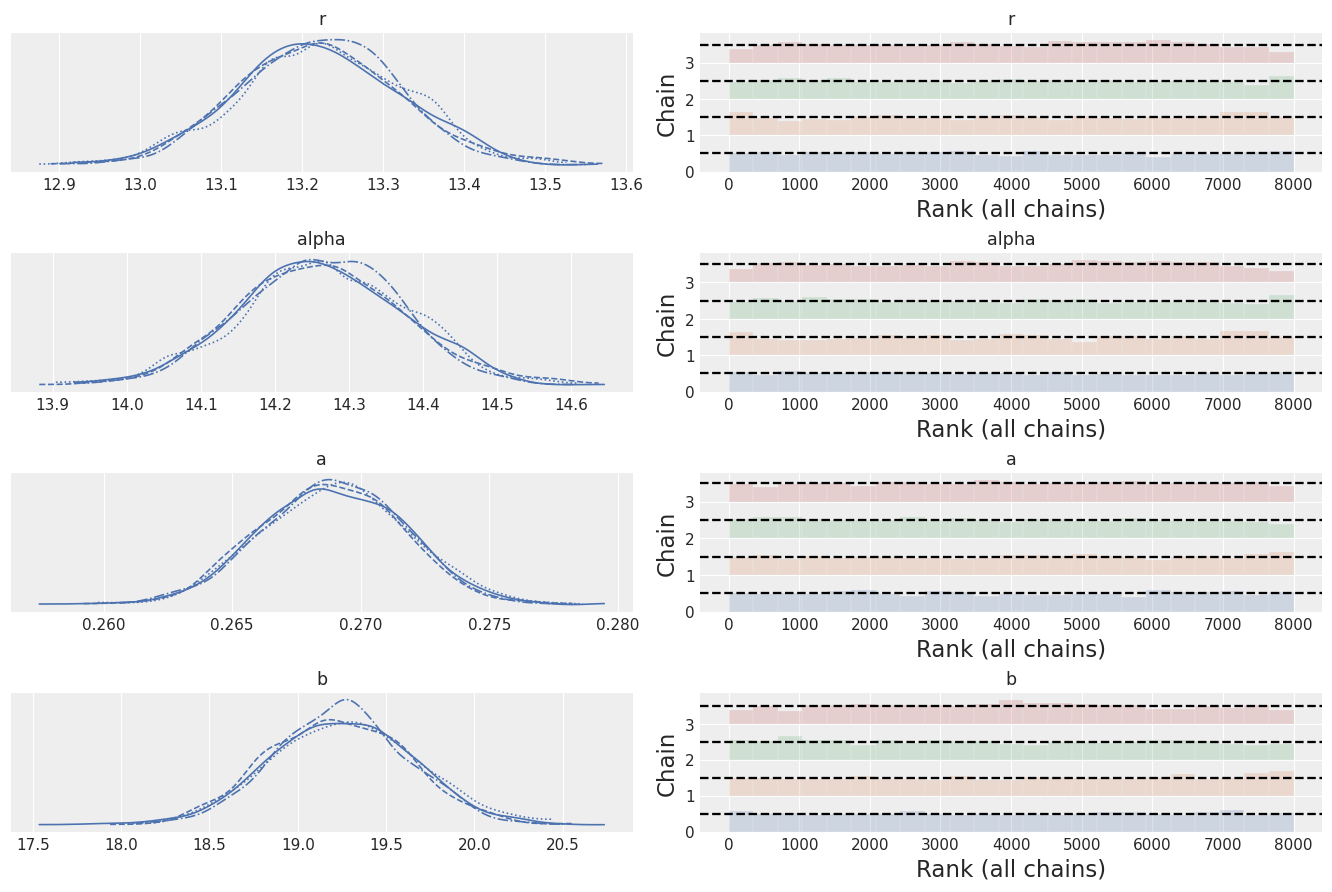

In [7]:
az.plot_trace(
    bgnbd.idata,
    var_names=VARS_BG,
    compact=True,
    kind="rank_bars",
    backend_kwargs={"figsize": (12, 8), "layout": "constrained"},
)
plt.show()

## 2.5 Análisis predictivo del BG/NBD

Una vez ajustado y diagnosticado el modelo, lo usamos para responder las preguntas operativas del TFM. Siguiendo la referencia de `pymc-marketing`, mostramos cuatro análisis:

1. **MAP vs MCMC** — comparación del optimizador puntual (L-BFGS-B sobre el log-posterior) con la posterior completa, como sanity check de que el MAP cae dentro de la masa central del posterior MCMC.
2. **Expected purchases** sobre un horizonte futuro de 90 semanas para usuarios concretos, con bandas de incertidumbre.
3. **$P(\text{vivo})$** sobre el mismo horizonte — el decaimiento de la probabilidad posterior de seguir activo a medida que pasa el tiempo sin nuevas validaciones.
4. **Probabilidad de cero transacciones** en los próximos $t$ períodos.

Los tres últimos se calculan sobre una **muestra estratificada de 10 usuarios** que representa el rango completo de comportamientos del dataset.

In [8]:
# Ajuste MAP del mismo modelo (cacheado igual que el MCMC)
CACHE_BGNBD_MAP = MODELS_DIR / f"bgnbd_map_{PRIORS_DEFAULT_KEY}_n{len(data_full)}.nc"

if CACHE_BGNBD_MAP.exists() and not FORCE_REFIT:
    print(f"Cargando MAP cacheado: {CACHE_BGNBD_MAP.name}")
    bgnbd_map = clv.BetaGeoModel.load(CACHE_BGNBD_MAP)
else:
    bgnbd_map = clv.BetaGeoModel(
        data=data_full,
        model_config=priors_to_model_config(PRIORS[PRIORS_DEFAULT_KEY])
    )
    print("Ajustando BG/NBD por MAP (L-BFGS-B)...")
    t0 = time.time()
    bgnbd_map.fit(method="map")
    print(f"MAP completo en {time.time()-t0:.1f} s. Guardando cache...")
    bgnbd_map.save(CACHE_BGNBD_MAP)
    print(f"✓ Modelo MAP guardado en {CACHE_BGNBD_MAP.name}")

# Resumen MAP
print("\nEstimaciones puntuales MAP:")
for var in VARS_BG:
    val = float(bgnbd_map.idata.posterior[var].mean())
    print(f"  {var}: {val:.4f}")

Cargando MAP cacheado: bgnbd_map_elicited_n59995.nc

Estimaciones puntuales MAP:
  r: 13.2159
  alpha: 14.2569
  a: 0.2689
  b: 19.2482


C:\Users\andre\AppData\Local\Temp\ipykernel_33616\2037901805.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


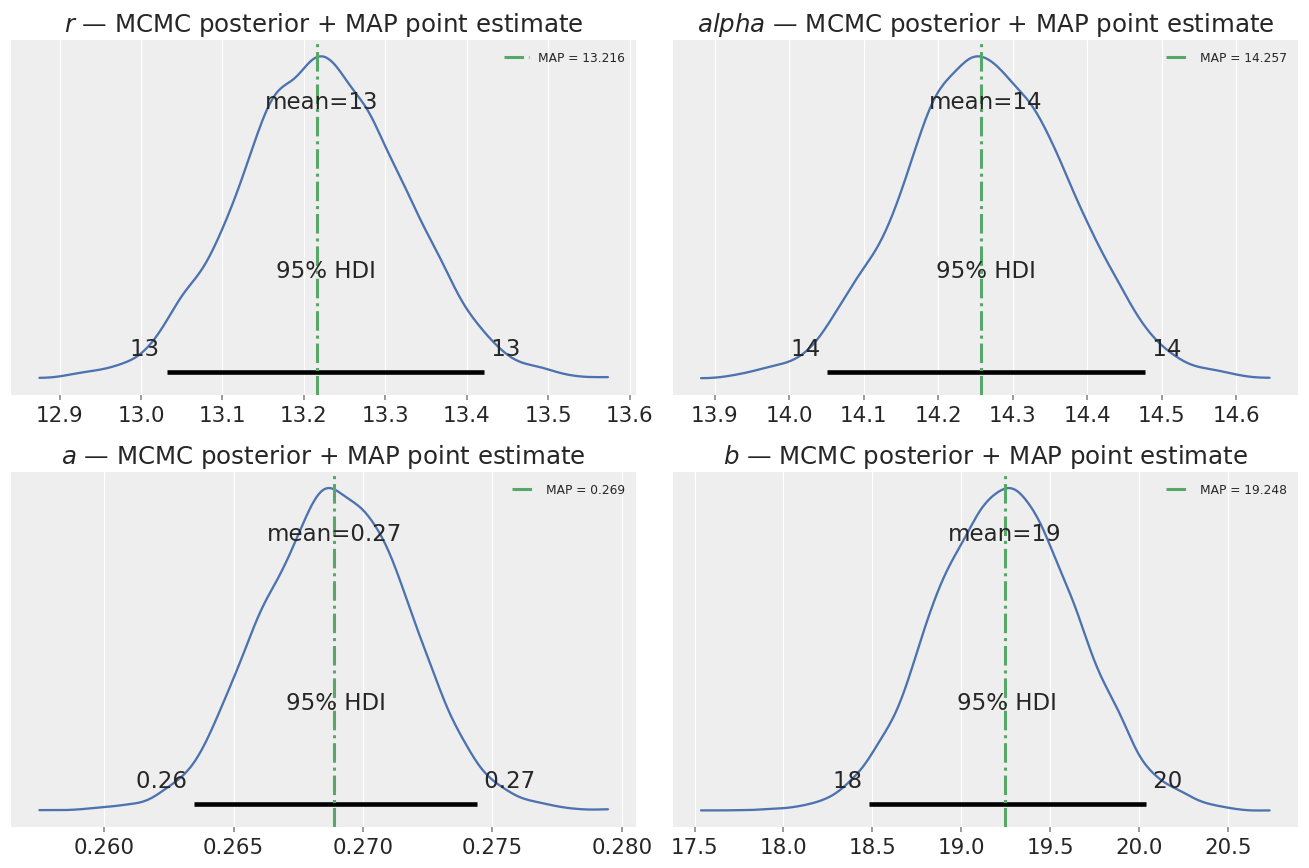

In [9]:
# Comparación MAP vs MCMC: superponer la estimación puntual sobre la posterior
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.ravel(), VARS_BG):
    az.plot_posterior(
        bgnbd.idata.posterior[var].values.flatten(),
        color="C0", point_estimate="mean", hdi_prob=0.95, ax=ax,
    )
    map_val  = float(bgnbd_map.idata.posterior[var].mean())
    true_val = PARAMS_CALIBRATED[var]
    ax.axvline(map_val,  color="C2", ls="-.", lw=2,
               label=f"MAP = {map_val:.3f}")
    ax.set_title(f"${var}$ — MCMC posterior + MAP point estimate")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# Muestra estratificada de 10 usuarios para los plots por usuario.
# Cubrimos el rango de comportamientos del dataset: frecuencia baja/media/alta
# combinada con dormancia baja/alta. Suficiente para que los gráficos cuenten
# la historia sin saturar.

q_freq = data_full["frequency"].quantile([0.25, 0.5, 0.75]).values
data_full = data_full.copy()
data_full["dormancia"] = data_full["T"] - data_full["recency"]
data_full["estrato_freq"] = pd.cut(
    data_full["frequency"],
    bins=[-1, q_freq[0], q_freq[1], q_freq[2], np.inf],
    labels=["frec_baja", "frec_media", "frec_alta", "frec_muy_alta"],
)

sample_customers = (
    data_full.groupby("estrato_freq", observed=True, group_keys=False)
            .apply(lambda d: d.sample(min(3, len(d)), random_state=SEED))
            .head(10)
            .reset_index(drop=True)
)
# Limpiamos para no contaminar otras celdas
data_full = data_full.drop(columns=["estrato_freq", "dormancia"])

print(f"Muestra de {len(sample_customers)} usuarios:")
print(sample_customers[["customer_id", "frequency", "recency", "T"]].to_string(index=False))

Muestra de 10 usuarios:
   customer_id  frequency  recency     T
USR_2018_02291         17     17.0 416.0
USR_2018_17609          7      7.0 416.0
USR_2018_08363          7      7.0 416.0
USR_2018_22239         92     92.0 416.0
USR_2024_00296         85     92.0 104.0
USR_2021_03528         90     92.0 260.0
USR_2018_05430        246    264.0 416.0
USR_2022_00918        201    207.0 208.0
USR_2023_07454        150    155.0 156.0
USR_2018_21635        374    415.0 416.0


Calculando E[X(t)] para t = 1..90 semanas sobre 10 usuarios...
Hecho en 10.3 s


C:\Users\andre\AppData\Local\Temp\ipykernel_33616\2858017310.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


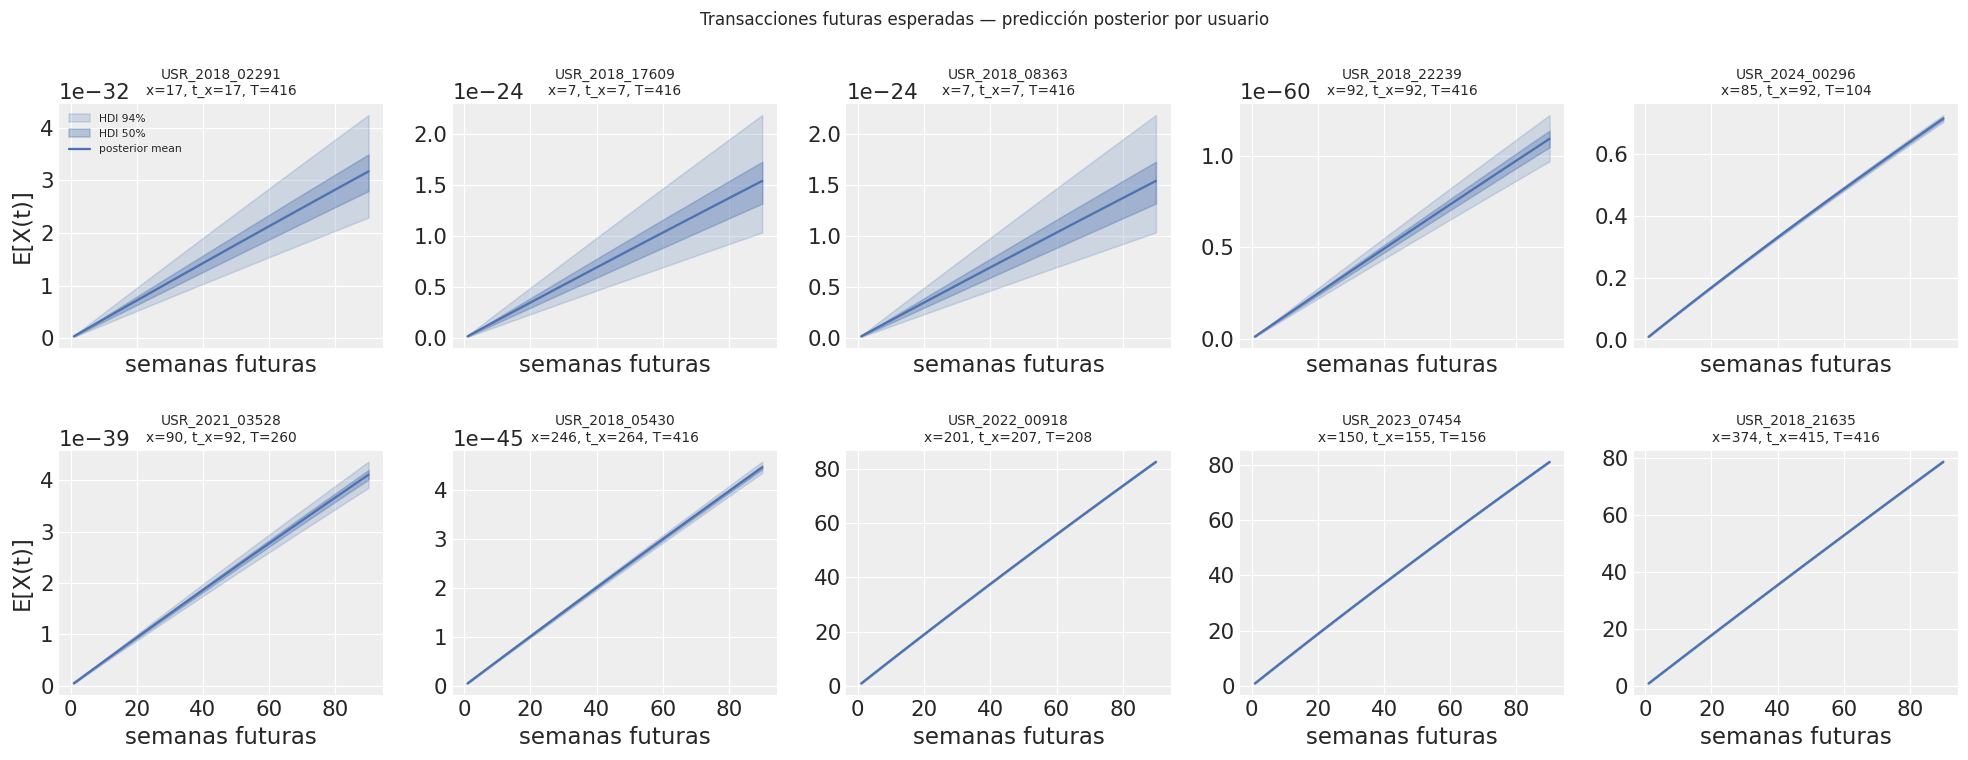

In [11]:
# Trayectoria de E[X(t)] para t = 1..90 semanas en la muestra de 10 usuarios.
# Calculamos posterior completo (chain, draw) en cada paso temporal y luego
# resumimos en mean + bandas HDI 94% y 50%.

steps = 90
print(f"Calculando E[X(t)] para t = 1..{steps} semanas sobre {len(sample_customers)} usuarios...")
t0 = time.time()
exp_purchases_steps = xr.concat(
    [bgnbd.expected_purchases(data=sample_customers, future_t=t)
     for t in range(1, steps + 1)],
    dim="future_t",
).assign_coords(future_t=np.arange(1, steps + 1))
print(f"Hecho en {time.time()-t0:.1f} s")

# Plot 2x5
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)
for ax, (_, cust) in zip(axes.ravel(), sample_customers.iterrows()):
    curve = exp_purchases_steps.sel(customer_id=cust["customer_id"])

    mean = curve.mean(dim=("chain", "draw"))
    lo94 = curve.quantile(0.03, dim=("chain", "draw"))
    hi94 = curve.quantile(0.97, dim=("chain", "draw"))
    lo50 = curve.quantile(0.25, dim=("chain", "draw"))
    hi50 = curve.quantile(0.75, dim=("chain", "draw"))

    t_grid = np.arange(1, steps + 1)
    ax.fill_between(t_grid, lo94, hi94, alpha=0.20, color="C0", label="HDI 94%")
    ax.fill_between(t_grid, lo50, hi50, alpha=0.35, color="C0", label="HDI 50%")
    ax.plot(t_grid, mean, color="C0", lw=1.5, label="posterior mean")

    ax.set_title(
        f"{cust['customer_id']}\nx={cust['frequency']}, "
        f"t_x={cust['recency']:.0f}, T={cust['T']:.0f}",
        fontsize=9,
    )
    ax.set_xlabel("semanas futuras")
axes[0, 0].set_ylabel("E[X(t)]")
axes[1, 0].set_ylabel("E[X(t)]")
axes[0, 0].legend(fontsize=7, loc="upper left")

plt.suptitle("Transacciones futuras esperadas — predicción posterior por usuario", fontsize=11)
plt.tight_layout()
plt.show()

Calculando P(vivo) en horizonte futuro de 90 semanas...
Hecho en 3.0 s


C:\Users\andre\AppData\Local\Temp\ipykernel_33616\2502145029.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


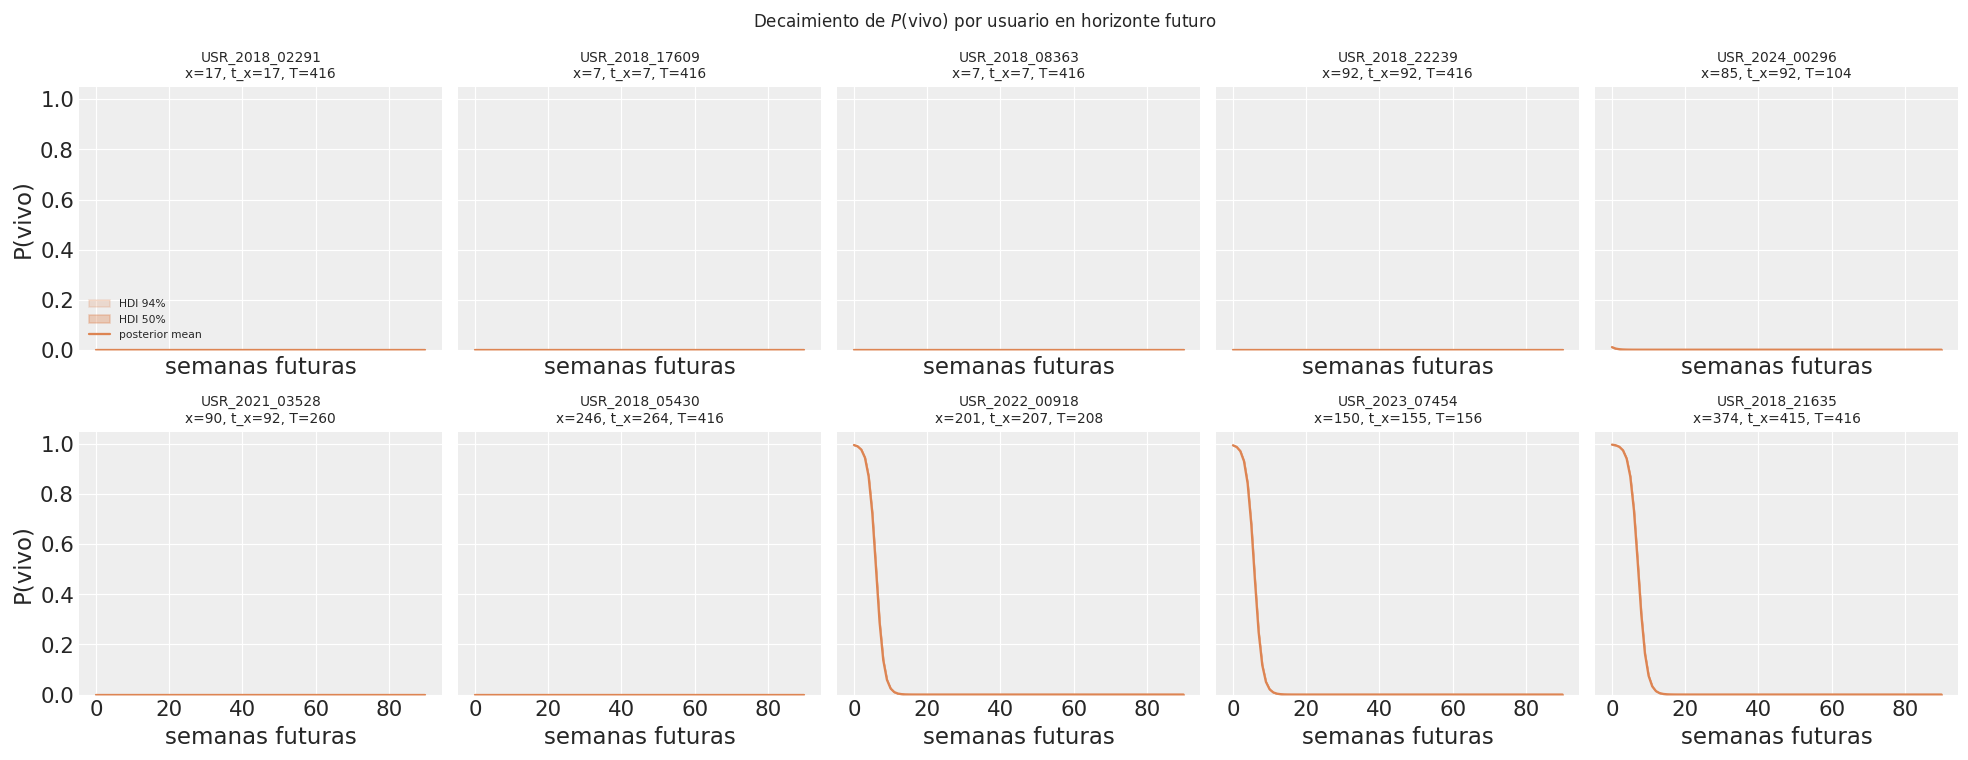

In [12]:
# P(vivo) en función del tiempo: para cada paso t avanzamos el T del usuario
# bajo el supuesto de que NO ocurren nuevas validaciones — eso modela la
# erosión natural de la confianza en que sigue activo.

steps = 90
print(f"Calculando P(vivo) en horizonte futuro de {steps} semanas...")
t0 = time.time()

p_alive_steps_list = []
for t in range(0, steps + 1):
    future_data = sample_customers.copy()
    future_data["T"] = future_data["T"] + t
    p_alive_steps_list.append(bgnbd.expected_probability_alive(data=future_data))

p_alive_steps = xr.concat(p_alive_steps_list, dim="future_t").assign_coords(
    future_t=np.arange(0, steps + 1)
)
print(f"Hecho en {time.time()-t0:.1f} s")

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
for ax, (_, cust) in zip(axes.ravel(), sample_customers.iterrows()):
    curve = p_alive_steps.sel(customer_id=cust["customer_id"])

    mean = curve.mean(dim=("chain", "draw"))
    lo94 = curve.quantile(0.03, dim=("chain", "draw"))
    hi94 = curve.quantile(0.97, dim=("chain", "draw"))
    lo50 = curve.quantile(0.25, dim=("chain", "draw"))
    hi50 = curve.quantile(0.75, dim=("chain", "draw"))

    t_grid = np.arange(0, steps + 1)
    ax.fill_between(t_grid, lo94, hi94, alpha=0.20, color="C1", label="HDI 94%")
    ax.fill_between(t_grid, lo50, hi50, alpha=0.35, color="C1", label="HDI 50%")
    ax.plot(t_grid, mean, color="C1", lw=1.5, label="posterior mean")

    ax.set_ylim(0, 1.05)
    ax.set_title(
        f"{cust['customer_id']}\nx={cust['frequency']}, "
        f"t_x={cust['recency']:.0f}, T={cust['T']:.0f}",
        fontsize=9,
    )
    ax.set_xlabel("semanas futuras")
axes[0, 0].set_ylabel("P(vivo)")
axes[1, 0].set_ylabel("P(vivo)")
axes[0, 0].legend(fontsize=7, loc="lower left")

plt.suptitle("Decaimiento de $P(\\text{vivo})$ por usuario en horizonte futuro", fontsize=11)
plt.tight_layout()
plt.show()

Calculando P(X=0 en próximas t semanas) para t = 1..30...
Hecho en 3.8 s


C:\Users\andre\AppData\Local\Temp\ipykernel_33616\2978001034.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


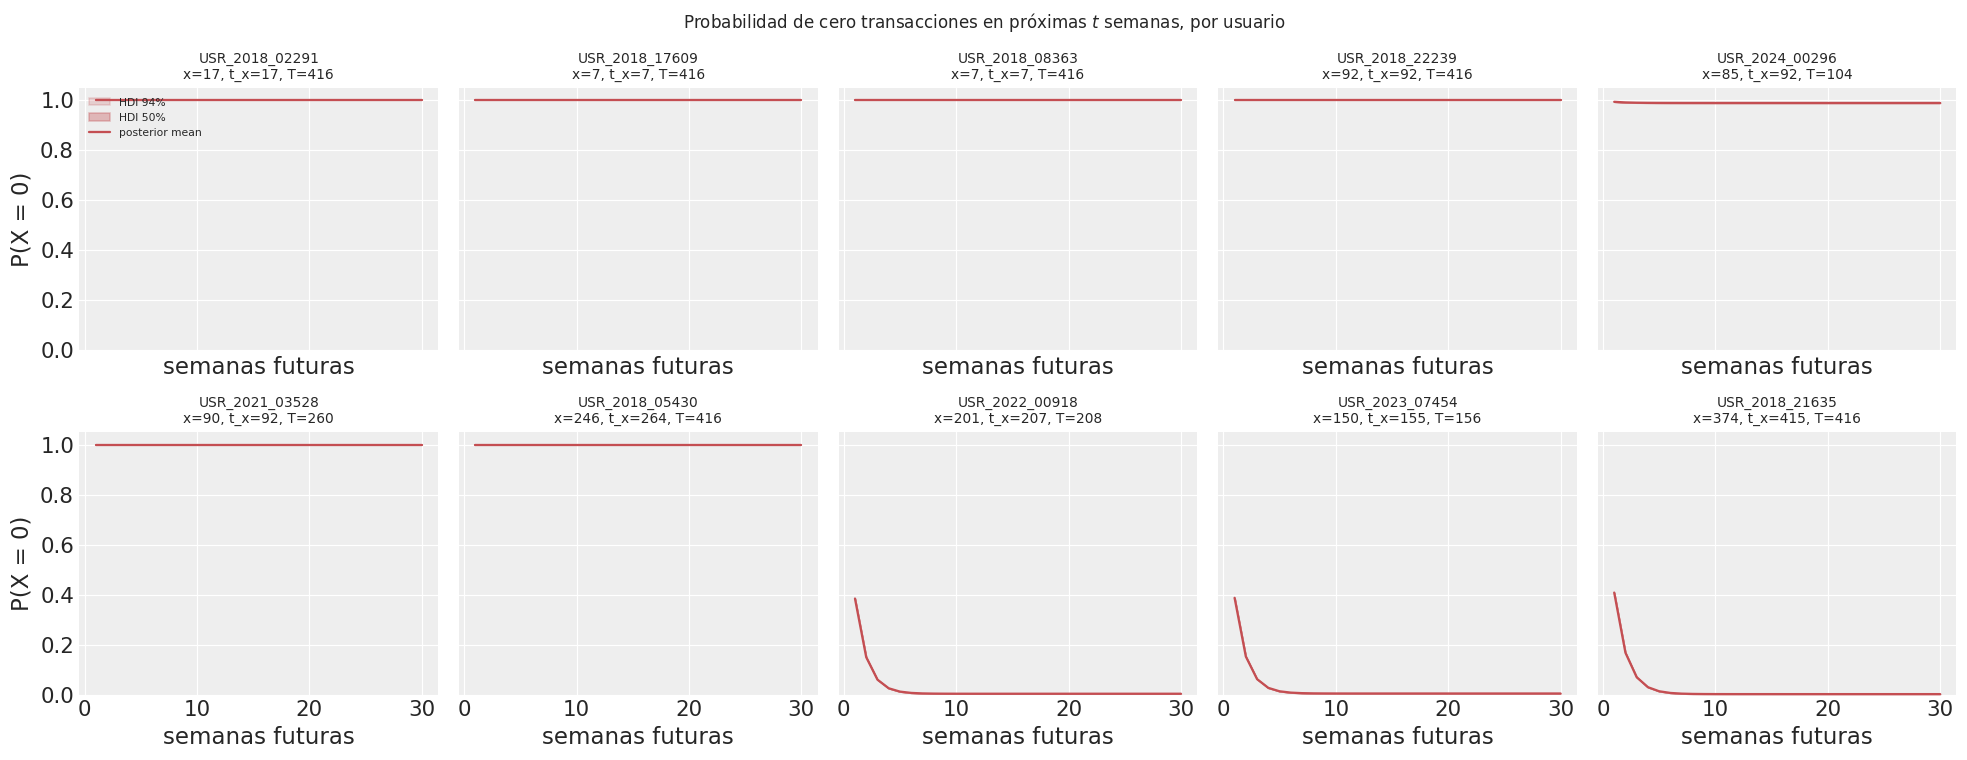

In [13]:
# Probabilidad de NO realizar ninguna transacción en los próximos t períodos.
# Es la dual de E[X(t)]: complementa la lectura mostrando explícitamente la
# probabilidad de inactividad en una ventana corta (30 semanas como en la
# referencia de pymc-marketing).

steps = 30
print(f"Calculando P(X=0 en próximas t semanas) para t = 1..{steps}...")
t0 = time.time()
p_no_purchase = xr.concat(
    [bgnbd.expected_probability_no_purchase(data=sample_customers, t=t)
     for t in range(1, steps + 1)],
    dim="future_t",
).assign_coords(future_t=np.arange(1, steps + 1))
print(f"Hecho en {time.time()-t0:.1f} s")

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
for ax, (_, cust) in zip(axes.ravel(), sample_customers.iterrows()):
    curve = p_no_purchase.sel(customer_id=cust["customer_id"])

    mean = curve.mean(dim=("chain", "draw"))
    lo94 = curve.quantile(0.03, dim=("chain", "draw"))
    hi94 = curve.quantile(0.97, dim=("chain", "draw"))
    lo50 = curve.quantile(0.25, dim=("chain", "draw"))
    hi50 = curve.quantile(0.75, dim=("chain", "draw"))

    t_grid = np.arange(1, steps + 1)
    ax.fill_between(t_grid, lo94, hi94, alpha=0.20, color="C3", label="HDI 94%")
    ax.fill_between(t_grid, lo50, hi50, alpha=0.35, color="C3", label="HDI 50%")
    ax.plot(t_grid, mean, color="C3", lw=1.5, label="posterior mean")

    ax.set_ylim(0, 1.05)
    ax.set_title(
        f"{cust['customer_id']}\nx={cust['frequency']}, "
        f"t_x={cust['recency']:.0f}, T={cust['T']:.0f}",
        fontsize=9,
    )
    ax.set_xlabel("semanas futuras")
axes[0, 0].set_ylabel("P(X = 0)")
axes[1, 0].set_ylabel("P(X = 0)")
axes[0, 0].legend(fontsize=7, loc="upper left")

plt.suptitle("Probabilidad de cero transacciones en próximas $t$ semanas, por usuario",
             fontsize=11)
plt.tight_layout()
plt.show()

## 3. Modelo Gamma-Gamma

### Recordatorio matemático

Sea $z_{ij}$ el gasto del usuario $i$ en su transacción $j$. El modelo Gamma-Gamma supone:

$$
z_{ij} \mid \nu_i \sim \mathrm{Gamma}(p,\, \nu_i), \qquad \nu_i \sim \mathrm{Gamma}(q,\, \gamma)
$$

donde $\nu_i$ es el parámetro de "escala" individual y $(p, q, \gamma)$ son hiperparámetros poblacionales. La media marginal del gasto por transacción del usuario $i$ es:

$$
\mathbb{E}[z_i \mid \bar{z}_i, x_i] \;=\; \frac{p\,\gamma + \bar{z}_i\,x_i\,p}{x_i\,p + q - 1}
$$

Se ajusta sólo sobre `data_recurring` porque la fórmula requiere al menos una observación de gasto por usuario.

In [14]:
CACHE_GG = MODELS_DIR / f"gg_n{len(data_recurring)}.nc"

if CACHE_GG.exists() and not FORCE_REFIT:
    print(f"Cargando modelo Gamma-Gamma cacheado: {CACHE_GG.name}")
    gg = clv.GammaGammaModel.load(CACHE_GG)
else:
    gg = clv.GammaGammaModel(data=data_recurring)
    gg.build_model()

    print(f"Ajustando Gamma-Gamma sobre {len(data_recurring):,} usuarios recurrentes...")
    t0 = time.time()
    gg.fit(**MCMC_CONFIG)
    dt = (time.time() - t0) / 60
    print(f"Fit completo en {dt:.1f} minutos. Guardando cache...")
    gg.save(CACHE_GG)
    print(f"✓ Modelo guardado en {CACHE_GG}")

Cargando modelo Gamma-Gamma cacheado: gg_n59123.nc


In [15]:
print(gg)

Gamma-Gamma Model (Mean Transactions)
         p ~ HalfFlat()
         q ~ HalfFlat()
         v ~ HalfFlat()
likelihood ~ Potential(f(q, p, v))


In [16]:
VARS_GG = ["p", "q", "v"]
summary_gg = az.summary(gg.idata, var_names=VARS_GG, hdi_prob=0.95, round_to=4)
print("Resumen posterior Gamma-Gamma (HDI 95 %):")
print(summary_gg)

n_div_gg = int(gg.idata.sample_stats["diverging"].sum())
print(f"\nDivergencias: {n_div_gg}  {'✓' if n_div_gg == 0 else '✗'}")

Resumen posterior Gamma-Gamma (HDI 95 %):
     mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd   ess_bulk  \
p  5.5826  0.2851    5.0270     6.1431     0.0106   0.0072   730.8791   
q  9.4884  0.0599    9.3777     9.6126     0.0012   0.0009  2499.1494   
v  6.3519  0.3403    5.6990     7.0216     0.0126   0.0080   727.5108   

    ess_tail   r_hat  
p   681.9449  1.0021  
q  2206.6897  1.0012  
v   739.9511  1.0022  

Divergencias: 0  ✓


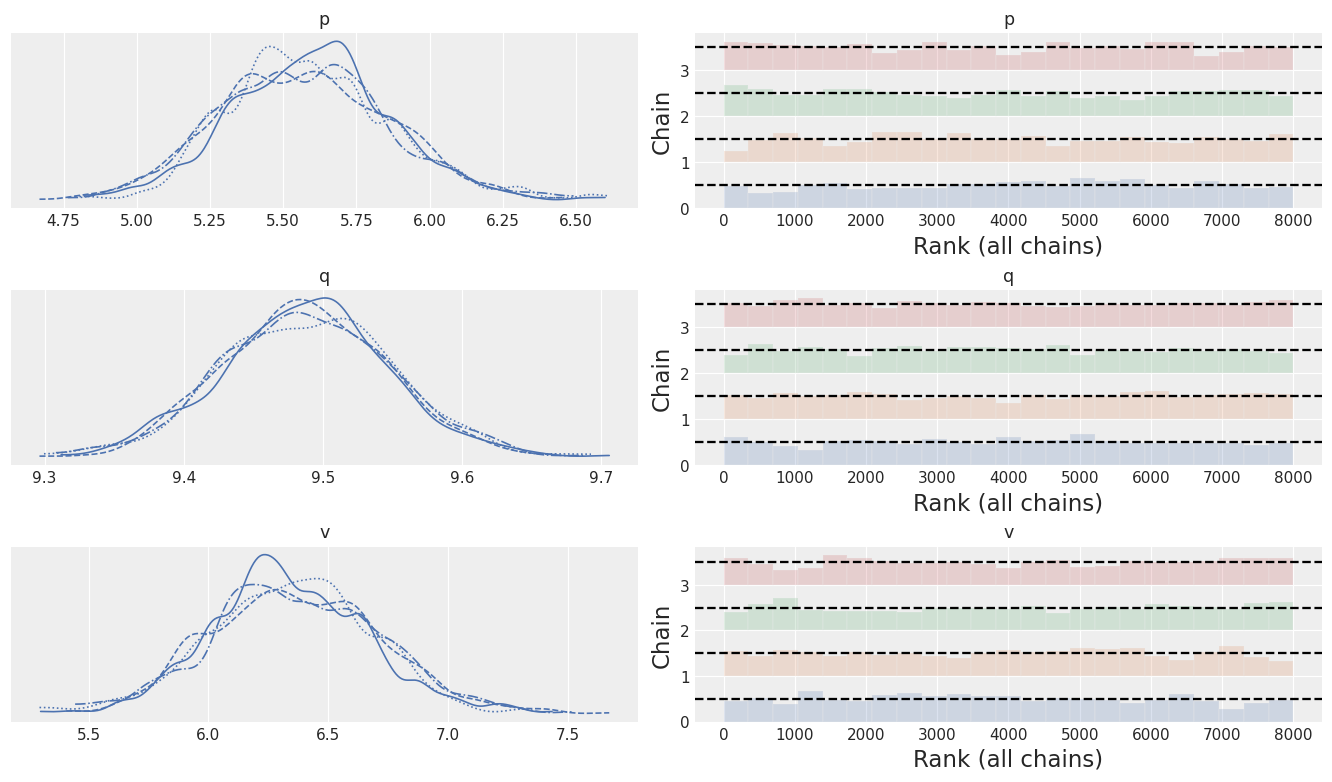

In [17]:
az.plot_trace(
    gg.idata,
    var_names=VARS_GG,
    compact=True,
    kind="rank_bars",
    backend_kwargs={"figsize": (12, 7), "layout": "constrained"},
)
plt.show()

## 4. Predicciones individuales

Tres cantidades por usuario, cada una con su distribución posterior completa:

1. $P(\text{vivo} \mid x, t_x, T)$ — probabilidad posterior de seguir activo hoy.
2. $\mathbb{E}[X_i(t)]$ — número de validaciones esperadas en los próximos $t$ semanas (de BG/NBD).
3. $\mathbb{E}[\bar{z}_i]$ — gasto esperado por transacción (de Gamma-Gamma).

In [18]:
# Sampleo estratificado proporcional por (tipo_titulo, es_joven) → preserva
# la mezcla del dataset completo, así que la segmentación sigue siendo válida.
# Las posteriores poblacionales de (r, alpha, a, b) NO se ven afectadas;
# esas siguen ajustadas sobre los 60k del modelo MCMC.

N_ANALYSIS = 10000

estrato = (rfm["tipo_titulo"].astype(str) + "_" + rfm["es_joven"].astype(str))
data_analysis = (
    rfm.assign(_estrato=estrato)
       .groupby("_estrato", group_keys=False)
       .apply(lambda d: d.sample(
           n=max(1, int(round(N_ANALYSIS * len(d) / len(rfm)))),
           random_state=SEED))
       [["customer_id", "frequency", "recency", "T", "monetary_value"]]
       .reset_index(drop=True)
)
data_recurring_analysis = data_analysis.query("frequency > 0").reset_index(drop=True)

print(f"Muestra de análisis: {len(data_analysis):,} usuarios "
      f"({100*len(data_analysis)/len(data_full):.1f}% del total)")
print(f"  Recurrentes:        {len(data_recurring_analysis):,}")

print("\nProporciones preservadas (population vs muestra):")
ids_sample = set(data_analysis["customer_id"])
rfm_sample = rfm[rfm["customer_id"].isin(ids_sample)]
for col in ["tipo_titulo", "es_joven"]:
    full_pct = rfm[col].value_counts(normalize=True).sort_index()
    samp_pct = rfm_sample[col].value_counts(normalize=True).sort_index()
    for k in full_pct.index:
        print(f"  {col} = {str(k):20s}: full={full_pct[k]:.3f}   muestra={samp_pct[k]:.3f}")

Muestra de análisis: 10,000 usuarios (16.7% del total)
  Recurrentes:        9,832

Proporciones preservadas (population vs muestra):
  tipo_titulo = bono_30_dias        : full=0.129   muestra=0.129
  tipo_titulo = monedero_metro      : full=0.232   muestra=0.232
  tipo_titulo = ocasional           : full=0.061   muestra=0.061
  tipo_titulo = tarjeta_consorcio   : full=0.578   muestra=0.578
  es_joven = False               : full=0.874   muestra=0.874
  es_joven = True                : full=0.126   muestra=0.126


In [19]:
p_alive = bgnbd.expected_probability_alive(data=data_analysis)

p_alive_med = p_alive.median(dim=("chain", "draw")).to_pandas()
p_alive_lo  = p_alive.quantile(0.025, dim=("chain", "draw")).to_pandas()
p_alive_hi  = p_alive.quantile(0.975, dim=("chain", "draw")).to_pandas()

print(f"P(vivo) calculado sobre muestra de {len(data_analysis):,} usuarios.\n")
print(f"  Mediana poblacional: {p_alive_med.median():.3f}")
print(f"  Ancho medio HDI 95%: {(p_alive_hi - p_alive_lo).mean():.3f}")
print(f"  Usuarios 'muertos' (P_alive_med < 0.1):  {(p_alive_med < 0.1).sum():,}")
print(f"  Usuarios 'vivos'    (P_alive_med > 0.9): {(p_alive_med > 0.9).sum():,}")

P(vivo) calculado sobre muestra de 10,000 usuarios.

  Mediana poblacional: 0.990
  Ancho medio HDI 95%: 0.000
  Usuarios 'muertos' (P_alive_med < 0.1):  4,814
  Usuarios 'vivos'    (P_alive_med > 0.9): 5,157


In [20]:
# Número esperado de transacciones futuras a 1, 3 y 5 años (en semanas)
HORIZONTES_AÑOS = [1, 3, 5]
HORIZONTES_SEM  = {a: a * 52 for a in HORIZONTES_AÑOS}

expected_purchases = {}
for años, t_sem in HORIZONTES_SEM.items():
    print(f"Calculando E[X(t={t_sem} sem.)] sobre {len(data_analysis):,} usuarios...")
    expected_purchases[años] = bgnbd.expected_purchases(
        data=data_analysis,
        future_t=t_sem,
    )

print("\nMediana de transacciones esperadas (en la muestra):")
for años, da in expected_purchases.items():
    med = da.median(dim=("chain", "draw")).median().item()
    print(f"  {años} año(s) ({años*52} semanas): {med:.1f} transacciones por usuario")

Calculando E[X(t=52 sem.)] sobre 10,000 usuarios...
Calculando E[X(t=156 sem.)] sobre 10,000 usuarios...
Calculando E[X(t=260 sem.)] sobre 10,000 usuarios...

Mediana de transacciones esperadas (en la muestra):
  1 año(s) (52 semanas): 24.4 transacciones por usuario
  3 año(s) (156 semanas): 71.2 transacciones por usuario
  5 año(s) (260 semanas): 115.8 transacciones por usuario


In [21]:
# Gasto esperado por transacción del Gamma-Gamma — calculado sobre la muestra
# de recurrentes. Lo guardamos como `expected_spend_recurring` y lo reutilizamos
# en la celda de CLV (evitar recomputar es importante porque cada llamada es lenta).

print(f"Calculando expected_customer_spend sobre {len(data_recurring_analysis):,} recurrentes...")
expected_spend_recurring = gg.expected_customer_spend(data=data_recurring_analysis)
spend_med_population = float(expected_spend_recurring.median())

spend_med_recurring = (
    expected_spend_recurring.median(dim=("chain", "draw"))
                            .to_pandas()
)

print(f"\nGasto esperado por transacción (en \"viajes\" — multiplicar por precio):")
print(f"  Mediana poblacional: {spend_med_population:.2f} viajes/transacción")
print(f"  En euros (× {PRECIO_VIAJE} €/viaje): {spend_med_population * PRECIO_VIAJE:.2f} €/transacción")

Calculando expected_customer_spend sobre 9,832 recurrentes...

Gasto esperado por transacción (en "viajes" — multiplicar por precio):
  Mediana poblacional: 3.91 viajes/transacción
  En euros (× 0.66 €/viaje): 2.58 €/transacción


## 5. CLV a 1, 3 y 5 años

Combinamos las dos predicciones por usuario:

$$
\mathrm{CLV}_i(t) \;=\; \mathbb{E}[X_i(t)] \;\times\; \mathbb{E}[\bar{z}_i] \;\times\; \text{precio del viaje}
$$

donde el primer factor es del BG/NBD y el segundo del Gamma-Gamma. Manejamos las distribuciones posteriores completas (no sólo medianas) para propagar la incertidumbre hasta el CLV final.

In [22]:
# 1) Reutilizamos `expected_spend_recurring` calculado en la celda anterior
#    (evitar recomputar — es la llamada más cara).
spend_pop_mean = float(expected_spend_recurring.mean())
customer_ids_analysis = expected_purchases[1].customer_id.values

# Para usuarios no recurrentes (frequency = 0) Gamma-Gamma no produce
# predicción individual. Usamos la media poblacional posterior como fallback,
# reindexando sobre el conjunto de customer_ids de la muestra de análisis.
spend_post_full = expected_spend_recurring.reindex(
    customer_id=customer_ids_analysis,
    fill_value=spend_pop_mean,
)

# 2) CLV posterior por horizonte = transacciones × spend × precio del viaje
clv_posterior = {
    años: expected_purchases[años] * spend_post_full * PRECIO_VIAJE
    for años in HORIZONTES_AÑOS
}

# 3) Resumen poblacional con HDI 90 %
print(f"CLV poblacional (€) — calculado sobre muestra de {len(data_analysis):,} usuarios:\n")
filas = []
for años, clv_da in clv_posterior.items():
    medianas = clv_da.median(dim=("chain", "draw"))     # mediana posterior por usuario
    filas.append({
        "horizonte":   f"{años} año(s)",
        "CLV mediano": float(medianas.median()),
        "HDI 5%":      float(medianas.quantile(0.05)),
        "HDI 95%":     float(medianas.quantile(0.95)),
    })
tabla_clv = pd.DataFrame(filas)
print(tabla_clv.to_string(index=False, formatters={
    "CLV mediano": "{:.2f} €".format,
    "HDI 5%":      "{:.2f} €".format,
    "HDI 95%":     "{:.2f} €".format,
}))

CLV poblacional (€) — calculado sobre muestra de 10,000 usuarios:

horizonte CLV mediano HDI 5%  HDI 95%
 1 año(s)     32.91 € 0.00 € 190.47 €
 3 año(s)     93.62 € 0.00 € 542.39 €
 5 año(s)    151.36 € 0.00 € 871.70 €


C:\Users\andre\AppData\Local\Temp\ipykernel_33616\311340975.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


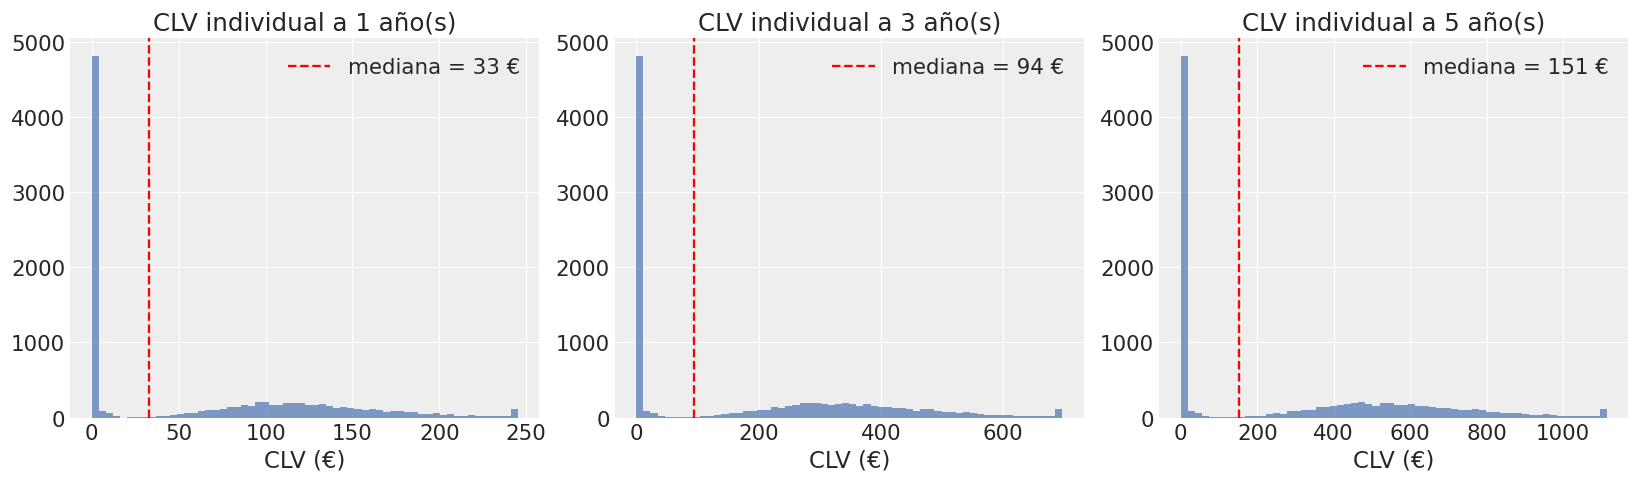

In [23]:
# Distribución del CLV mediano por usuario, para cada horizonte
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (años, clv_da) in zip(axes, clv_posterior.items()):
    clv_med_user = clv_da.median(dim=("chain", "draw")).to_pandas()
    upper = clv_med_user.quantile(0.99)
    ax.hist(clv_med_user.clip(0, upper), bins=60, color="C0", alpha=0.7)
    ax.axvline(clv_med_user.median(), color="red", ls="--",
                label=f"mediana = {clv_med_user.median():.0f} €")
    ax.set_title(f"CLV individual a {años} año(s)")
    ax.set_xlabel("CLV (€)")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Segmentación: CLV por subpoblación

El objetivo específico (5) de la propuesta del TFM es comparar la dinámica de abandono y valor entre universitarios y residentes permanentes. Aquí lo materializamos con cortes del CLV por las tres variables categóricas del dataset: `tipo_titulo`, `cohort_year` y `es_joven`.

In [24]:
# clv_summary contiene una fila por usuario de la MUESTRA con sus variables
# originales (tipo_titulo, cohort_year, es_joven) + columnas de CLV.
customer_ids = data_analysis["customer_id"].values

clv_summary = rfm.set_index("customer_id").reindex(customer_ids).copy()
for años, clv_da in clv_posterior.items():
    series = clv_da.median(dim=("chain", "draw")).to_pandas().reindex(customer_ids)
    clv_summary[f"clv_{años}y"] = series.values
clv_summary["p_alive_med"] = p_alive_med.reindex(customer_ids).values

print(f"CLV calculado para muestra de {len(clv_summary):,} usuarios\n")

print("CLV a 5 años por tipo de título:")
print(clv_summary.groupby("tipo_titulo")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2)
                  .sort_values("median", ascending=False))

print("\nCLV a 5 años por es_joven:")
print(clv_summary.groupby("es_joven")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2))

print("\nCLV a 5 años por cohorte:")
print(clv_summary.groupby("cohort_year")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2))

CLV calculado para muestra de 10,000 usuarios

CLV a 5 años por tipo de título:
                   median    mean  count
tipo_titulo                             
ocasional          280.74  309.10    607
bono_30_dias       238.73  296.61   1293
monedero_metro     166.05  295.65   2316
tarjeta_consorcio   60.27  293.03   5784

CLV a 5 años por es_joven:
          median    mean  count
es_joven                       
False     184.99  283.55   8740
True       49.39  375.02   1260

CLV a 5 años por cohorte:
             median    mean  count
cohort_year                       
2018           0.00  243.42   4430
2019           0.00  235.15    651
2020          13.49  312.24    116
2021           0.00  297.83    891
2022         299.23  338.74   1318
2023         395.38  368.27   1296
2024         397.41  364.32    838
2025         449.33  410.15    460


C:\Users\andre\AppData\Local\Temp\ipykernel_33616\3783862107.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


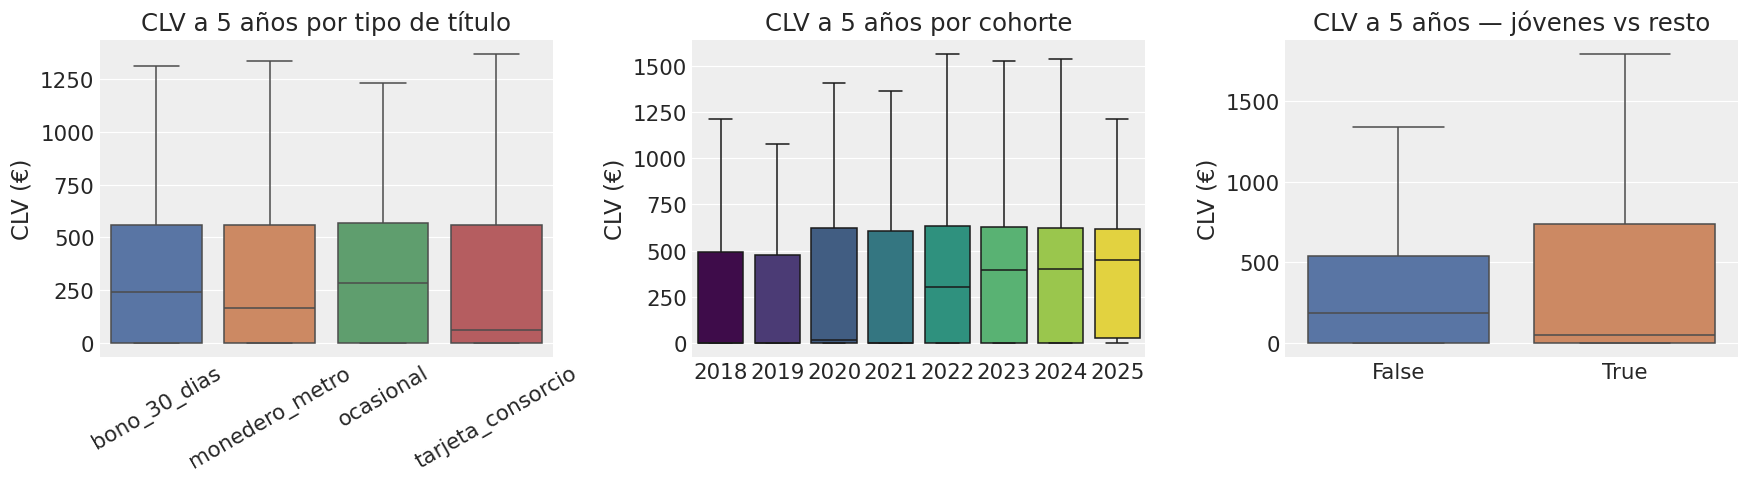

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Por tipo de título
ax = axes[0]
sns.boxplot(data=clv_summary, x="tipo_titulo", y="clv_5y", ax=ax,
             showfliers=False, hue="tipo_titulo", legend=False)
ax.tick_params(axis="x", rotation=30)
ax.set_title("CLV a 5 años por tipo de título")
ax.set_ylabel("CLV (€)")
ax.set_xlabel("")

# (b) Por cohorte
ax = axes[1]
sns.boxplot(data=clv_summary, x="cohort_year", y="clv_5y", ax=ax,
             showfliers=False, palette="viridis", hue="cohort_year", legend=False)
ax.set_title("CLV a 5 años por cohorte")
ax.set_ylabel("CLV (€)")
ax.set_xlabel("")

# (c) Universitarios vs no
ax = axes[2]
sns.boxplot(data=clv_summary, x="es_joven", y="clv_5y", ax=ax,
             showfliers=False, hue="es_joven", legend=False)
ax.set_title("CLV a 5 años — jóvenes vs resto")
ax.set_ylabel("CLV (€)")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

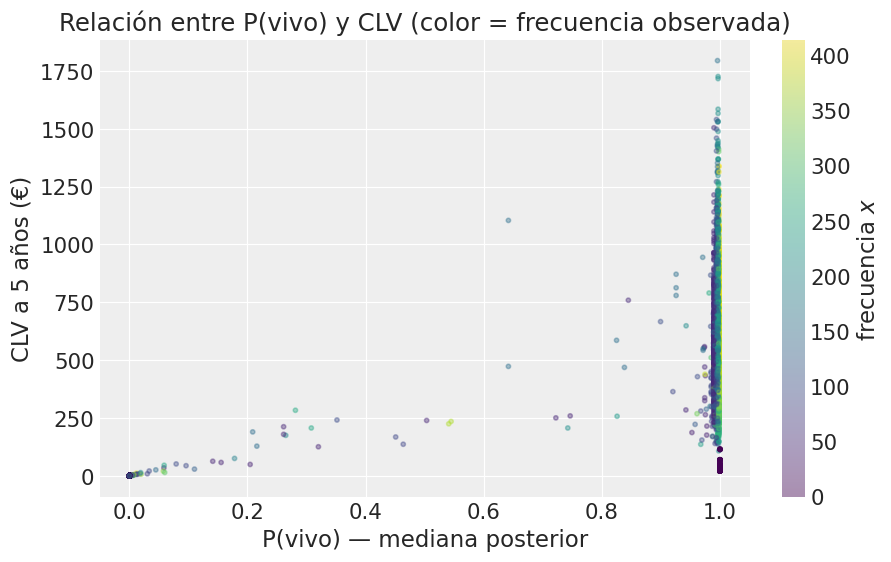

In [26]:
# P(vivo) vs CLV: los "vivos" valen más; los "muertos" tienen CLV bajo.
# Usamos constrained_layout porque la barra de color añade un eje que
# no se lleva bien con plt.tight_layout().
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sc = ax.scatter(clv_summary["p_alive_med"], clv_summary["clv_5y"],
                 c=clv_summary["frequency"], cmap="viridis",
                 alpha=0.4, s=8)
ax.set_xlabel("P(vivo) — mediana posterior")
ax.set_ylabel("CLV a 5 años (€)")
ax.set_title("Relación entre P(vivo) y CLV (color = frecuencia observada)")
fig.colorbar(sc, ax=ax, label="frecuencia $x$")
plt.show()